# PROPHECG-Age Single Inference Notebook

This notebook demonstrates the following steps:

1. Load pretrained model weights (`models/model.pth`)
2. Load and visualize the sample ECG input (`data/sample_input.csv`)
3. Import and apply the ECG preprocessing pipeline
4. Perform inference to predict age from the preprocessed ECG signal

In [14]:
import os
os.chdir('/home/wellysis/PROPHECG_Age_Single_home')
print("Current work-directory:", os.getcwd())

Current work-directory: /home/wellysis/PROPHECG_Age_Single_home


## Sample ECG Data Loading & Raw Signal Visualization & Preprocessing Visualization


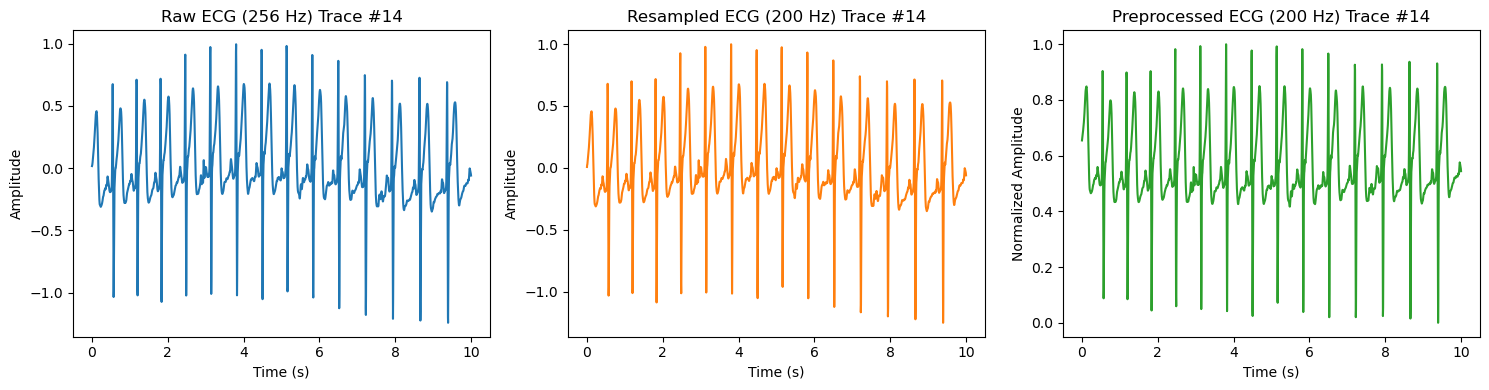

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample
from src.preprocess import preprocess_ecg

# 1) Load CSV and determine trace number
csv_path = 'data/sample_trace_14.csv'
df = pd.read_csv(csv_path)
basename  = os.path.basename(csv_path)
trace_num = os.path.splitext(basename)[0].split('_')[-1]

# 2) Extract raw time & ECG (256 Hz)
time_raw = df['time'].values
ecg_raw  = df['ecg'].values

# 3) Resample to 200 Hz
fs_src = 256
fs_tgt = 200
n_tgt  = int(len(ecg_raw) * fs_tgt / fs_src)  # → 2000 samples
ecg_rs  = resample(ecg_raw, n_tgt)
time_rs = np.linspace(0, 10, n_tgt)

# 4) Preprocess the resampled signal
ecg_proc = preprocess_ecg(ecg_rs, fs=fs_tgt)

# 5) Plot all three signals side by side
plt.figure(figsize=(15, 4))

# (a) Raw signal (256 Hz)
plt.subplot(1, 3, 1)
plt.plot(time_raw, ecg_raw, color='C0')
plt.title(f'Raw ECG (256 Hz) Trace #{trace_num}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# (b) Resampled signal (200 Hz)
plt.subplot(1, 3, 2)
plt.plot(time_rs, ecg_rs, color='C1')
plt.title(f'Resampled ECG (200 Hz) Trace #{trace_num}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# (c) Preprocessed signal (200 Hz)
plt.subplot(1, 3, 3)
plt.plot(time_rs, ecg_proc, color='C2')
plt.title(f'Preprocessed ECG (200 Hz) Trace #{trace_num}')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')

plt.tight_layout()
plt.show()


## Model Loading & AI-ECG Age estimating


In [38]:
import os
import sys
import torch

# 1) Add src folder to Python path (relative to notebook root)
project_root = os.getcwd()
sys.path.insert(0, os.path.join(project_root, 'src'))

# 2) Import model class
from resnet import ResNet1d_mse

# 3) Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 4) Hyperparameters
N_LEADS = 1
SEQ_LEN = ecg_proc.shape[0]        # typically 2000
BLOCKS  = [(32,2000),(64,400),(128,80),(256,16),(512,4)]
KERNEL  = 7
DROPOUT = 0.4
SCALE   = 5                        # scale factor used during training

# 5) Initialize model
model = ResNet1d_mse(
    input_dim=(N_LEADS, SEQ_LEN),
    blocks_dim=BLOCKS,
    n_classes=1,
    kernel_size=KERNEL,
    dropout_rate=DROPOUT
)

# 6) Load pretrained weights
weight_path = os.path.join(project_root, 'models', 'model.pth')
checkpoint = torch.load(weight_path, map_location=device)
state_dict = checkpoint.get('model', checkpoint)
model.load_state_dict(state_dict)

# 7) Switch to evaluation mode and move model to device
model.to(device)
model.eval()

# 8) Convert preprocessed ECG to tensor
#    ecg_proc: NumPy array, shape (2000,)
x = torch.from_numpy(ecg_proc.astype('float32')).unsqueeze(0).unsqueeze(0).to(device)  # shape (1,1,SEQ_LEN)

# 9) Run inference
with torch.no_grad():
    output = model(x).item()

# 10) Rescale and print prediction
predicted_age = output * SCALE
print(f"▶ Predicted ECG Age: {predicted_age:.2f} years")


Using device: cuda
▶ Predicted ECG Age: 49.92 years


---

## Results Summary

- **Raw ECG**: `data/sample_input.csv`
- **Preprocessed ECG**: DC offset removal → bandpass filter → normalization
- **Predicted Age**: `<value printed in cell>` years

This pipeline allows anyone to reproduce ECG-Age prediction using the provided model weights.
